In [1]:
# importing libraries
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast 
import seaborn as sns 

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_list(lists):
    if pd.notna(lists):
        return ast.literal_eval(lists)
df['job_skills'] = df['job_skills'].apply(clean_list)


/opt/anaconda3/envs/python_da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


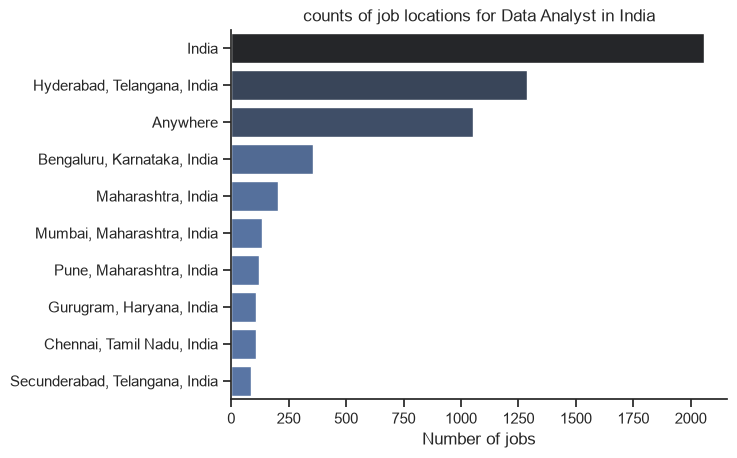

In [2]:
# filter for indian data analyst role
df_india = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst') ] 
df_plot = df_india['job_location'].value_counts().reset_index().head(10)
sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x= 'count', y='job_location', hue= 'count', palette='dark:b_r', legend= False )
sns.despine()
plt.title('counts of job locations for Data Analyst in India')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()


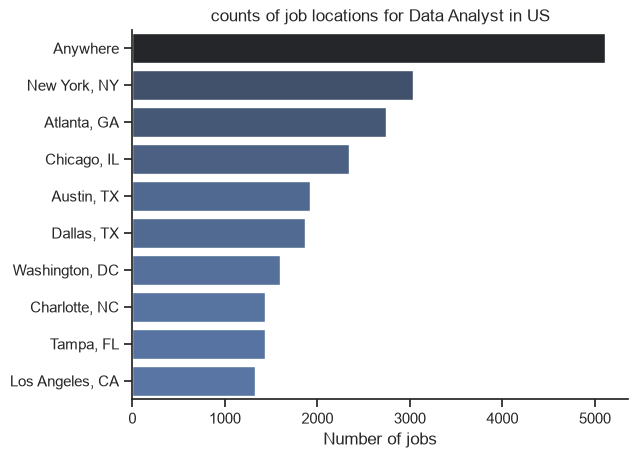

In [3]:
# filter for United States data analyst role
df_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst') ] 
df_plot_US = df_US['job_location'].value_counts().reset_index().head(10)
sns.set_theme(style='ticks')
sns.barplot(data = df_plot_US, x= 'count', y='job_location', hue= 'count', palette='dark:b_r', legend= False )
sns.despine()
plt.title('counts of job locations for Data Analyst in US')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()


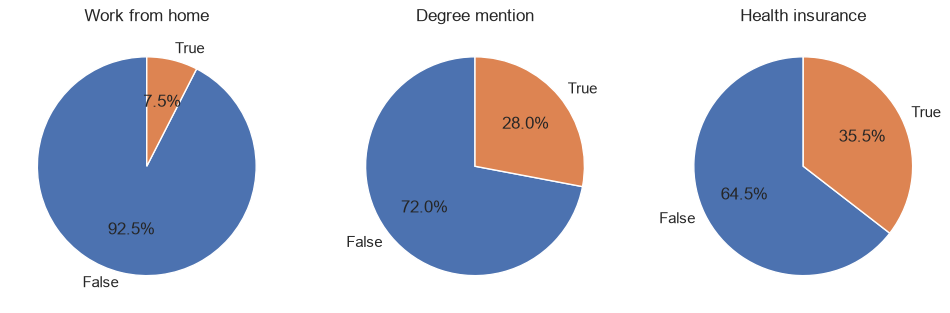

In [4]:
dict_items = {'job_work_from_home' : 'Work from home',
              'job_no_degree_mention' : 'Degree mention',
              'job_health_insurance' : 'Health insurance'}
fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column, title) in enumerate(dict_items.items()):
    counts = df_US[column].value_counts()
    ax[i].pie(counts, labels = counts.index, autopct= '%1.1f%%', startangle = 90)
    ax[i].set_title(title)


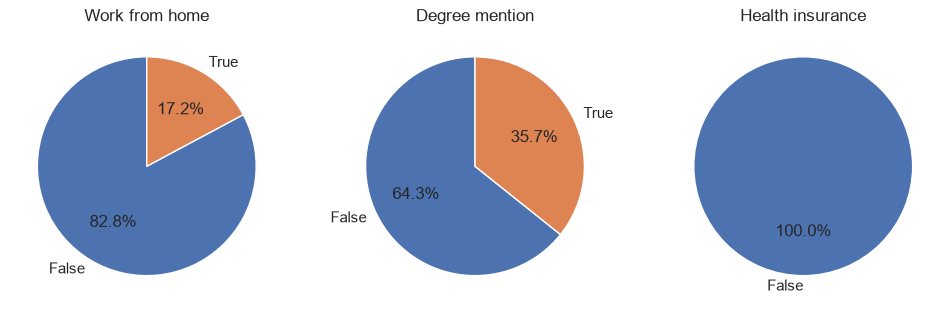

In [5]:
dict_items = {'job_work_from_home' : 'Work from home',
              'job_no_degree_mention' : 'Degree mention',
              'job_health_insurance' : 'Health insurance'}
fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column, title) in enumerate(dict_items.items()):
    counts = df_india[column].value_counts()
    ax[i].pie(counts, labels = counts.index, autopct= '%1.1f%%', startangle = 90)
    ax[i].set_title(title)


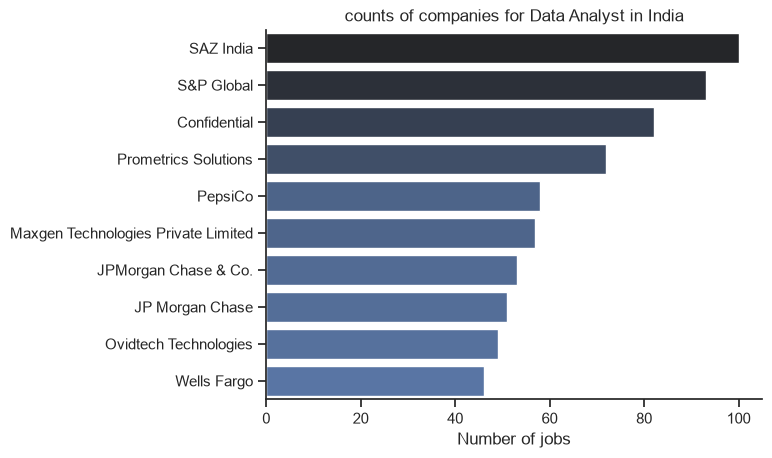

In [6]:
df_plot_2 = df_india['company_name'].value_counts().reset_index().head(10)
sns.set_theme(style='ticks')
sns.barplot(data = df_plot_2, x= 'count', y='company_name', hue= 'count', palette='dark:b_r', legend= False )
sns.despine()
plt.title('counts of companies for Data Analyst in India')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()

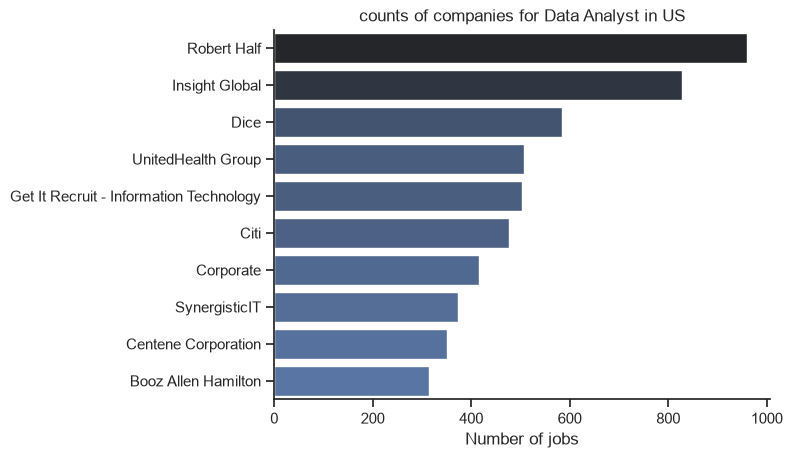

In [7]:
df_plot_us_2 = df_US['company_name'].value_counts().reset_index().head(10)
sns.set_theme(style='ticks')
sns.barplot(data = df_plot_us_2, x= 'count', y='company_name', hue= 'count', palette='dark:b_r', legend= False )
sns.despine()
plt.title('counts of companies for Data Analyst in US')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()
